In [1]:
###!/usr/bin/env python
################################################
# New style 
# ###############################################
import sys
import os

rootdir_ = '../'
if ( rootdir_ not in sys.path ):
    sys.path.append(rootdir_)
    print( f" a path to {rootdir_} added in {__name__} ")


from Utils import GridUtils as GrU
from Utils import utils as uti
from Utils import MyConstants as Co
from Utils import time_utils as tuti
from Utils import numerical_utils as nuti
##
from Regridder import VertRegridFlexLL as vrg

#from PyRegridding.Utils import MakePressures as MkP
#from Drivers import RegridField as RgF
import RegridField as RgF

# The usual
from datetime import date
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Some other useful packages 
import copy
import time
import cftime
import yaml
import numbers

# Some other useful packages 
import importlib
from pathlib import Path

Rdair=Co.Rdair()


 a path to ../ added in __main__ 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
Using Flexible parallel/serial VertRegrid 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
 a path to /glade/work/juliob added in Utils.numerical_utils 


In [2]:
def make_rho( X ):
    te = X.T.values
    pint=X.PINT.values
    nt,nz,ny,nx = np.shape( te )
    pmid = 0.5*( pint[:,0:nz,:,:] + pint[:,1:nz+1,:,:] )
    te_int = np.zeros( (nt,nz+1,ny,nx) )
    te_int[:,0,:]=te[:,0,:,:]
    te_int[:,nz,:]=te[:,nz-1,:,:]
    for z in np.arange( start=1,stop=nz ):
        te_int[:,z,:] = 0.5*( te[:,z-1,:] + te[:,z,:] )
    rho = pint / (Rdair * te_int )

    return rho


In [6]:
year,month,day,hour=2016,8,1,3
nsteps= 8 #26*8-2
dates=[f"{year:04d}-{month:02d}-{day:02d}-{hour*3_600:05d}"]
for n in np.arange( nsteps-1 ):
    year,month,day,hour = tuti.increment_hours( [year,month,day,hour], nhours=3 )
    date_=f"{year:04d}-{month:02d}-{day:02d}-{hour*3_600:05d}"
    #print( date_ )
    dates.append( date_ )


In [7]:
print( dates )

['2016-08-01-10800', '2016-08-01-21600', '2016-08-01-32400', '2016-08-01-43200', '2016-08-01-54000', '2016-08-01-64800', '2016-08-01-75600', '2016-08-02-00000']


In [8]:

case1 = 'cam77_dyamond1_prod1'
base1=f'/glade/derecho/scratch/juliob/archive/{case1}/atm/hist/DynVars_dyamond_fv1x1'
case2 = 'c124_dyamond1_prod2'
base2=f'/glade/derecho/scratch/juliob/archive/{case2}/atm/hist/DynVars_dyamond_fv1x1'

files1,files2 = [] , []

for date in dates:
    f1 = f'{base1}.{date}.nc'
    files1.append( f1 )
    f2 = f'{base2}.{date}.nc'
    files2.append( f2 )



In [9]:
%%time
X2=xr.open_mfdataset( files2 ,  data_vars='different', coords='different', compat='no_conflicts'   )

X1=xr.open_mfdataset( files1 ,  data_vars='different', coords='different', compat='no_conflicts'   )


CPU times: user 1.96 s, sys: 1.22 s, total: 3.19 s
Wall time: 11.2 s


In [25]:
zilev=X1.ilev.values
zg_1=X1.zgrid.values
pint_1=X1.PINT.values
pint_2=X2.PINT.values


In [11]:
print( zilev[6] )

23860.8301


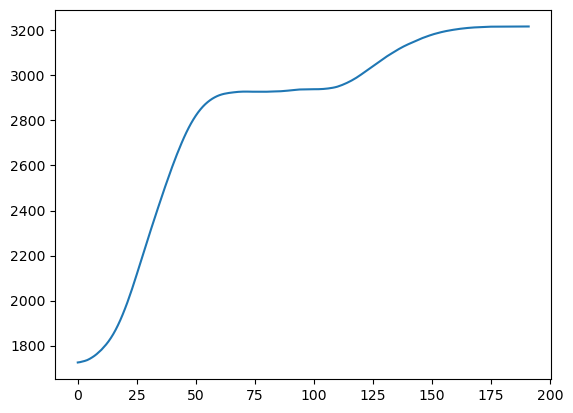

In [12]:
#plt.scatter( pint_1[0,6,:,:].flatten() , 0.001*zg_1[6,:,:].flatten() )
plt.plot( np.mean( pint_1[ 0, 6, :, :] , axis=1 ) )


In [13]:
if ('upwp' in X1):
    upwp_1 = X1.upwp.values 
elif ('Upwp' in X1):
    upwp_1 = X1.Upwp.values 

if ('vpwp' in X1):
    vpwp_1 = X1.vpwp.values 
elif ('Vpwp' in X1):
    vpwp_1 = X1.Vpwp.values 

#vpwp = X.vpwp.values


#epwp_1 = np.sqrt( upwp_1**2 + vpwp_1**2 )
#rho1=make_rho( X1 )
#rho_epwp_1 = rho1 * epwp_1

if ('upwp' in X2):
    upwp_2 = X2.upwp.values 
elif ('Upwp' in X2):
    upwp_2 = X2.Upwp.values 

if ('vpwp' in X2):
    vpwp_2 = X2.vpwp.values 
elif ('Vpwp' in X2):
    vpwp_2 = X2.Vpwp.values 

#vpwp = X.vpwp.values

In [15]:
pint_1.shape

(8, 59, 192, 288)

In [18]:
u_1 = X1.U.values

In [20]:
nt, nz, ny, nx = np.shape( u_1 )

plevs = np.asarray( [100_000.,50_000.,10_000., 5_000., 2_500. , 1_000., 500., 100. ] )
#pint_Dst = plevs[None, :, None, None]

pint_Dst = np.tile(plevs[None, :, None, None], (nt, 1, ny, nx) )

#pint_Dst = np.broadcast_to(plevs[None, :, None, None], (nt, nlev, ny, nx))

In [26]:
DstTZHkey = 'tzyx'

upwp_1_Dst = vrg.VertRG( a_x  = upwp_1 ,
                        zSrc = pint_1 ,
                        zDst = pint_Dst ,
                        Gridkey =DstTZHkey ,
                        kind = 'linear' ) #linea
    


upwp_2_Dst = vrg.VertRG( a_x  = upwp_2 ,
                        zSrc = pint_2 ,
                        zDst = pint_Dst ,
                        Gridkey =DstTZHkey ,
                        kind = 'linear' ) #linea
    






#epwp_2 = np.sqrt( upwp_2**2 + vpwp_2**2 )
#rho2=make_rho( X2 )
#rho_epwp_2 = rho2 * epwp_2

Flexible VertRegrid using reshaped ARRAYS 
nworkers available  1
Using serial code which is faster for 1 worker
Pll'zd Vertical int 11.3622 seconds
Flexible VertRegrid using reshaped ARRAYS 
nworkers available  1
Using serial code which is faster for 1 worker
Pll'zd Vertical int 10.7027 seconds


In [29]:
upwp_1_Dst.shape

(8, 8, 192, 288)

In [27]:
nt,nz,ny,nx = np.shape(upwp_1)
#for n in np.arange( nt ):
#    print( f" {n} ... {np.max(upwp_1[n,:,:,:])} ")

In [28]:

grav=Co.grav()
zlev=X1.lev.values
lat=X1.lat.values
lon=X1.lon.values

reso='3.75km'

ftopo='/glade/work/juliob/Topo/NCARTopoJTB/cases/fv1x1_Sco100_GrnlAnt/output/fv1x1_gmted2010_modis_bedmachine_nc3000_Laplace0100_noleak_greenlndantarcsgh30fac2.50_20251009.nc'
Topo=xr.open_dataset( ftopo )
htopo=Topo.PHIS.values/grav


In [ ]:
from scipy.ndimage import uniform_filter
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors



z=np.argmin( np.abs( zlev - 23_000. ) )

title_ = f'Z={zlev[z]/1000.:.0f} km '     #        camsnap-yaaaa.h.2004-06-15-21600.nc'


#flev=[0.0001,0.0002,0.0005,  0.001,0.002,0.005,  0.01,0.02,0.05,  0.1,0.2,0.5,   1.0  ]
flev=[0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.2,0.5,   1.0  ]
flev=0.1*np.asarray( flev )
print(flev)
cmapN='gist_ncar'

cmap = plt.cm.bwr  #gist_ncar  # Or any other colormap
cmap = plt.cm.gist_ncar # .plasma #gist_ncar  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

topocolor='white' #'black'
topocolor='black'


fig,axs=plt.subplots( 1, 2, figsize=(30,6) )

ax=axs[0]
c = ax.contourf( lon, lat, np.average(rho_epwp_1[:,z,:,:],axis=0) ,levels=flev, cmap=cmap , norm=norm, extend='both'  )
#c = ax.contourf( lon, lat, np.average(epwp_1[:,z,:,:],axis=0) ,levels=21, cmap=cmap , extend='both'  )
to = ax.contour( lon, lat, htopo, levels=[1,100] ,colors=topocolor)
ax.set_title( f'Resolved GW {r"$\tau$"} in {case1}: {reso} sim.')
plt.colorbar( c )

ax=axs[1]
c = ax.contourf( lon, lat, np.average(rho_epwp_2[:,z,:,:],axis=0) ,levels=flev, cmap=cmap , norm=norm, extend='both'  )
to = ax.contour( lon, lat, htopo, levels=[1,100] ,colors=topocolor)
ax.set_title( f'Resolved GW {r"$\tau$"} in {case2}: {reso} sim.')
plt.colorbar( c )

plt.suptitle( title_ , fontsize=24) 

print(X1.lev[z].values)
print(zlev[z])


In [ ]:
z0,lat0,lon0 =25_000., 12. , 250. 
z0,lat0,lon0 =25_000., -52. , 130. 
#z0,lat0,lon0 =25_000., -12. , 180. 

t,z,y,x = 15, np.argmin( np.abs( zlev - z0 ) ) , np.argmin( np.abs( zlev - lat0 ) ) , np.argmin( np.abs( lon - lon0 ) )


In [ ]:

plt.plot( np.average(rho_epwp_1[:,1:,y,x],axis=0) , zlev )
plt.plot( np.average(rho_epwp_2[:,1:,y,x],axis=0) , zlev )
plt.xlim(0.,0.01)


In [ ]:
u_1 , v_1 = X1.U.values , X1.V.values
u_2 , v_2 = X2.U.values , X2.V.values


In [ ]:
nt,nz,ny,nx = np.shape( u_1 )
zeta_1 = np.zeros( ( nt,nz,ny,nx) )
zeta_2= np.zeros( ( nt,nz,ny,nx) )

for t in np.arange( nt ):
    for z in np.arange( nz ):
        zeta_1[t,z,:,:] = nuti.Sphere_Curl2( f_x=u_1[t,z,:,:]  , f_y=v_1[t,z,:,:] , lat=lat, lon=lon , wrap=True, verbose=False)
        zeta_2[t,z,:,:] = nuti.Sphere_Curl2( f_x=u_2[t,z,:,:]  , f_y=v_2[t,z,:,:] , lat=lat, lon=lon , wrap=True, verbose=False)


In [ ]:
days=np.arange( nt ) # * 3./24.
plt.contourf( days, zlev ,zeta_2[:,:,y,x].T )
plt.contour( days, zlev ,rho_epwp_2[:,1:,y,x].T , levels= [.01,.1], colors='black')
plt.contour( days, zlev ,u_2[:,:,y,x].T , levels= [-10,-5,0,5,10,15,20,30,40] )#, colors='white')
plt.ylim( 0,15_000)

In [ ]:

epwp,vort,U,zl = rho_epwp_2[60,1:,y,x] , zeta_2[60,:,y,x] , u_2[60,:,y,x], zlev
fig, ax1 = plt.subplots(figsize=(5, 8))

# First variable: upwp
ax1.plot(epwp, zl, color='tab:blue', linewidth=2)
ax1.set_xlabel("upwp", color='tab:blue')
ax1.tick_params(axis='x', colors='tab:blue')
ax1.set_ylabel("z")

# Second variable: U
ax2 = ax1.twiny()
ax2.plot(U, zl, color='tab:orange', linewidth=2, linestyle='--')
ax2.set_xlabel("U", color='tab:orange')
ax2.tick_params(axis='x', colors='tab:orange')

# Third variable: vorticity
ax3 = ax1.twiny()
ax3.spines["top"].set_position(("axes", 1.12))   # move this x-axis upward
ax3.plot(vort, zl, color='tab:green', linewidth=2, linestyle=':')
ax3.set_xlabel("vorticity", color='tab:green')
ax3.tick_params(axis='x', colors='tab:green')

# Optional: if pressure or model level increases downward
# ax1.invert_yaxis()

plt.tight_layout()


In [ ]:
plt.plot( rho_epwp_2[:,6,y,x] )